In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Membaca dataset master
df = pd.read_csv('CH_Master_10Tahun_2015_2024.csv', delimiter=';')

# Mendefinisikan df_stasiun (Inilah variabel yang dicari oleh sistem)
df_stasiun = df[df['NAME'] == 'Stamet Pongtiku Tana Toraja'].copy()

In [3]:
# ==========================================================
# 1. KONFIGURASI MODEL HARIAN
# ==========================================================
STASIUN = 'Stamet Hasanuddin' 
LOOK_BACK = 30      # Membaca data 30 HARI ke belakang
LOOK_AHEAD = 30    
LSTM_UNITS = 128     # Diperbesar sedikit karena data harian lebih rumit
EPOCHS = 100
BATCH_SIZE = 8     # Diperbesar karena jumlah data mencapai ribuan baris

print(f"🚀 MEMULAI PIPELINE HARIAN UNTUK: {STASIUN}")
if not os.path.exists('Hasil_Eksperimen'): os.makedirs('Hasil_Eksperimen')

🚀 MEMULAI PIPELINE HARIAN UNTUK: Stamet Hasanuddin


In [4]:
# ==========================================================
# 2. FEATURE ENGINEERING (MENAMBAH FITUR BULAN)
# ==========================================================

print("\n[1/6] Membaca Dataset Master dan Membersihkan Data...")
df_all = pd.read_csv('CH_Master_10Tahun_2015_2024.csv', delimiter=';')
df_stasiun = df_all[df_all['NAME'] == STASIUN].copy()

# Pastikan urutan waktu benar (Sangat fatal untuk sekuensial harian)
df_stasiun['DATA TIMESTAMP'] = pd.to_datetime(df_stasiun['DATA TIMESTAMP'])
df_stasiun = df_stasiun.sort_values('DATA TIMESTAMP').reset_index(drop=True)

# Cleansing: Ubah 8888 dan 9999 jadi NaN
df_stasiun['RAINFALL DAY MM'] = df_stasiun['RAINFALL DAY MM'].replace([8888.0, 9999.0], np.nan)
df_stasiun['RAINFALL DAY MM'] = df_stasiun['RAINFALL DAY MM'].replace([8888.0, 9999.0], np.nan)
df_stasiun['RAINFALL DAY MM'] = df_stasiun['RAINFALL DAY MM'].interpolate(method='linear')
df_stasiun['RAINFALL DAY MM'] = df_stasiun['RAINFALL DAY MM'].fillna(0.0) 

# TRIK BARU: Ekstrak Bulan (1-12) sebagai fitur tambahan pendamping hujan
df_stasiun['Bulan'] = df_stasiun['DATA TIMESTAMP'].dt.month

# Sekarang dataset kita punya 2 kolom fitur (Multivariat Semu)
fitur_pilihan = ['RAINFALL DAY MM', 'Bulan']


[1/6] Membaca Dataset Master dan Membersihkan Data...


In [5]:
# ==========================================================
# 3. PEMBAGIAN DATA 70:30 (SEKUENSENSIAL HARIAN) & NORMALISASI
# ==========================================================
print("[2/6] Membagi Data berurutan: 60% Train dan 40% Test...")
total_data = len(df_stasiun)
batas_split = int(total_data * 0.60)

train_data = df_stasiun.iloc[:batas_split].copy()
test_data = df_stasiun.iloc[batas_split:].copy()

print(f"      -> Total Data Harian : {total_data} Hari")
print(f"      -> Data Train (60%)  : {len(train_data)} Hari")
print(f"      -> Data Test (40%)   : {len(test_data)} Hari")

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data[['RAINFALL DAY MM']].values)
test_scaled = scaler.fit_transform(test_data[['RAINFALL DAY MM']].values)
joblib.dump(scaler, f'Hasil_Eksperimen/scaler_harian_{STASIUN.replace(" / ", "_")}.pkl')

[2/6] Membagi Data berurutan: 60% Train dan 40% Test...
      -> Total Data Harian : 3653 Hari
      -> Data Train (60%)  : 2191 Hari
      -> Data Test (40%)   : 1462 Hari


['Hasil_Eksperimen/scaler_harian_Stamet Hasanuddin.pkl']

In [6]:
# ==========================================================
# 4. PEMBENTUKAN SEQUENCE MULTIVARIAT (AGAK BERBEDA SEDIKIT)
# ==========================================================
def create_multivariate_dataset(dataset, look_back, look_ahead):
    X, Y = [], []
    for i in range(len(dataset) - look_back - look_ahead + 1):
        # X mengambil semua kolom (Hujan dan Bulan)
        X.append(dataset[i:(i + look_back), :])
        # Y HANYA mengambil kolom Hujan (indeks 0) sebagai target
        Y.append(dataset[(i + look_back):(i + look_back + look_ahead), 0])
    return np.array(X), np.array(Y)

X_train, y_train = create_multivariate_dataset(train_scaled, LOOK_BACK, LOOK_AHEAD)
X_test, y_test = create_multivariate_dataset(test_scaled, LOOK_BACK, LOOK_AHEAD)

In [7]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [8]:
# ==========================================================
# 5. PELATIHAN MODEL LSTM
# ==========================================================
print(f"\n[4/6] Melatih Model Harian (Maks Epochs: {EPOCHS})...")
model = Sequential()
model.add(LSTM(units=LSTM_UNITS, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=LSTM_UNITS, return_sequences=True, input_shape=(LOOK_BACK, 1)))
model.add(Dropout(0.4))
model.add(LSTM(units=LSTM_UNITS, return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(units=LOOK_AHEAD))

# Tetap pakai Huber Loss karena data harian sangat rentan nilai ekstrem (outliers)
model.compile(optimizer='adam', loss=Huber(delta=1.0))

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

history = model.fit(X_train, y_train, 
                    epochs=EPOCHS, 
                    batch_size=BATCH_SIZE, 
                    validation_data=(X_test, y_test), 
                    verbose=1)

model.save(f'Hasil_Eksperimen/model_harian_{STASIUN.replace(" / ", "_")}.h5')


[4/6] Melatih Model Harian (Maks Epochs: 100)...


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 31s 85ms/step - loss: 0.0052 - val_loss: 0.0045
Epoch 2/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 26s 98ms/step - loss: 0.0049 - val_loss: 0.0045
Epoch 3/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - loss: 0.0048 - val_loss: 0.0045
Epoch 4/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 5/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 6/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 7/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 8/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 9/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 10/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 0.0048 - val_loss: 0.0044
Epoch 11/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 12/100
267/26

In [9]:
# ==========================================================
# 6. EVALUASI METRIK AKHIR
# ==========================================================
print("\n[5/6] Menghitung Metrik Evaluasi Akhir...")

pred_train_scaled = model.predict(X_train, verbose=0)
pred_test_scaled = model.predict(X_test, verbose=0)

y_train_asli = scaler.inverse_transform(y_train)
pred_train_asli = scaler.inverse_transform(pred_train_scaled)
y_test_asli = scaler.inverse_transform(y_test)
pred_test_asli = scaler.inverse_transform(pred_test_scaled)

def print_metrik(y_true, y_pred, label_dataset):
    print(f"\n{'='*40}")
    print(f"📊 HASIL EVALUASI {label_dataset}")
    print(f"{'='*40}")
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"MSE  : {mse:.4f}")
    print(f"MAE  : {mae:.4f} mm / hari")
    print(f"R²   : {r2:.4f}")

print_metrik(y_train_asli, pred_train_asli, "DATA TRAIN HARIAN (60%)")
print_metrik(y_test_asli, pred_test_asli, "DATA TEST HARIAN (40%)")


[5/6] Menghitung Metrik Evaluasi Akhir...

📊 HASIL EVALUASI DATA TRAIN HARIAN (60%)
MSE  : 211.1457
MAE  : 8.3235 mm / hari
R²   : 0.6682

📊 HASIL EVALUASI DATA TEST HARIAN (40%)
MSE  : 673.9912
MAE  : 15.0150 mm / hari
R²   : -0.1472


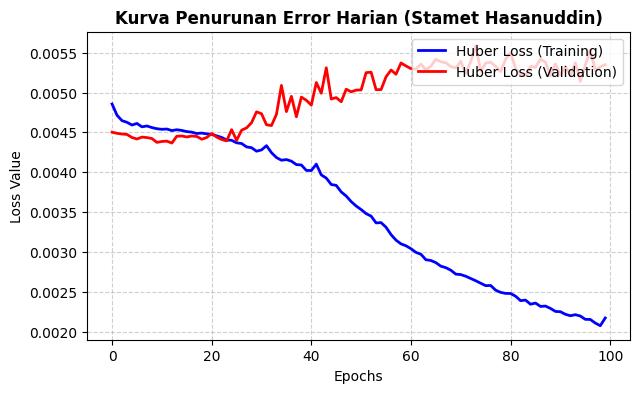

In [10]:
# ==========================================================
# 7. VISUALISASI GRAFIK
# ==========================================================
# ==========================================
# GRAFIK 1: KURVA PENURUNAN ERROR (LOSS CURVE)
# ==========================================
plt.figure(figsize=(7, 4)) # Mengatur ukuran kanvas grafik loss

# Plot loss training dan validation
plt.plot(history.history['loss'], label='Huber Loss (Training)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Huber Loss (Validation)', color='red', linewidth=2)

plt.title('Kurva Penurunan Error Harian (Stamet Hasanuddin)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Otomatis menyimpan grafik menjadi file gambar PNG berkualitas tinggi
plt.savefig('loss_hasanuddin.png', dpi=300, bbox_inches='tight')
plt.show()

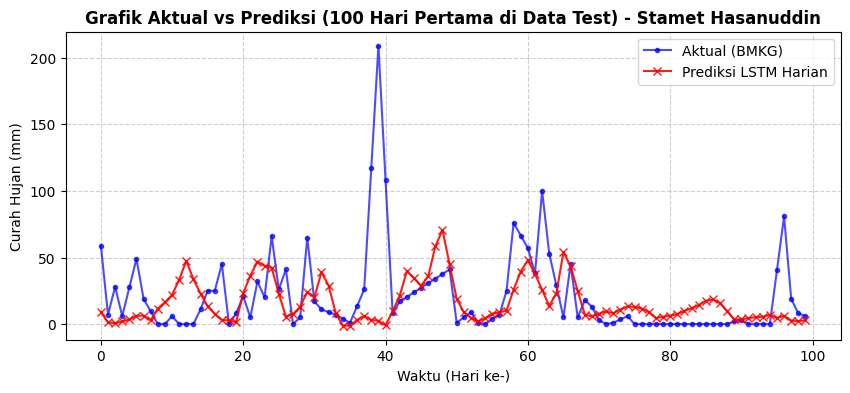

In [11]:
# ==========================================
# GRAFIK 2: AKTUAL VS PREDIKSI (DATA TESTING)
# ==========================================
plt.figure(figsize=(10, 4)) # Kanvas dibuat lebih lebar agar deret waktu terlihat jelas

# Menampilkan 100 hari pertama dari data pengujian agar tidak terlalu padat
plt.plot(y_test_asli[:100, 0], label='Aktual (BMKG)', color='blue', marker='.', alpha=0.7, linewidth=1.5)
plt.plot(pred_test_asli[:100, 0], label='Prediksi LSTM Harian', color='red', marker='x', alpha=0.9, linewidth=1.5)

plt.title('Grafik Aktual vs Prediksi (100 Hari Pertama di Data Test) - Stamet Hasanuddin', fontsize=12, fontweight='bold')
plt.xlabel('Waktu (Hari ke-)', fontsize=10)
plt.ylabel('Curah Hujan (mm)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Otomatis menyimpan grafik menjadi file gambar PNG berkualitas tinggi
plt.savefig('eval_hasanuddin.png', dpi=300, bbox_inches='tight')
plt.show()